<a href="https://colab.research.google.com/github/ImNotDanish05/2026_Pembelajaran-Mesin_TI-3A/blob/main/Week_3/Modul_Machine_Learning_Rev06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Kolom: x1, x2, target
data = np.array([
 [1,40,0],[2,43,0],[2,48,0],[3,50,0],[3,54,0],[4,55,0],[4,58,0],[5,60,0],
 [5,62,1],[6,60,0],[3,64,1],[6,64,1],[4,66,0],[7,63,1],[5,68,1],[7,67,1],
 [6,70,1],[8,68,1],[5,72,0],[8,72,1],[7,74,1],[9,73,1],[6,76,1],[9,76,1],
 [8,78,1],[10,77,1],[7,80,1],[10,80,1],[9,82,1],[11,81,1],[8,84,1],[11,85,1]
], dtype=float)

x1 = data[:,0]
x2 = data[:,1]
y  = data[:,2].astype(int)

z = -5.5 + 0.30*x1 + 0.065*x2
p = 1 / (1 + np.exp(-z))

def evaluate(threshold):
    pred = (p >= threshold).astype(int)
    cm = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y, pred)
    pre = precision_score(y, pred)
    rec = recall_score(y, pred)
    f1  = f1_score(y, pred)
    spec = tn / (tn + fp)
    print('Threshold =', threshold)
    print('Confusion matrix:', cm)
    print('TN, FP, FN, TP =', tn, fp, fn, tp)
    print('Accuracy    =', round(acc,4))
    print('Precision   =', round(pre,4))
    print('Recall      =', round(rec,4))
    print('Specificity =', round(spec,4))
    print('F1-score    =', round(f1,4))
    return pred

pred05 = evaluate(0.50)
pred06 = evaluate(0.60)

print('Detail threshold 0.50')
for i in range(len(y)):
    status = ('TP' if y[i]==1 and pred05[i]==1 else
              'TN' if y[i]==0 and pred05[i]==0 else
              'FP' if y[i]==0 and pred05[i]==1 else 'FN')
    print(i+1, 'z=', round(z[i],3), 'p=', round(p[i],3),
          'aktual=', y[i], 'pred=', pred05[i], status)

Threshold = 0.5
Confusion matrix: [[ 9  2]
 [ 1 20]]
TN, FP, FN, TP = 9 2 1 20
Accuracy    = 0.9062
Precision   = 0.9091
Recall      = 0.9524
Specificity = 0.8182
F1-score    = 0.9302
Threshold = 0.6
Confusion matrix: [[10  1]
 [ 2 19]]
TN, FP, FN, TP = 10 1 2 19
Accuracy    = 0.9062
Precision   = 0.95
Recall      = 0.9048
Specificity = 0.9091
F1-score    = 0.9268
Detail threshold 0.50
1 z= -2.6 p= 0.069 aktual= 0 pred= 0 TN
2 z= -2.105 p= 0.109 aktual= 0 pred= 0 TN
3 z= -1.78 p= 0.144 aktual= 0 pred= 0 TN
4 z= -1.35 p= 0.206 aktual= 0 pred= 0 TN
5 z= -1.09 p= 0.252 aktual= 0 pred= 0 TN
6 z= -0.725 p= 0.326 aktual= 0 pred= 0 TN
7 z= -0.53 p= 0.371 aktual= 0 pred= 0 TN
8 z= -0.1 p= 0.475 aktual= 0 pred= 0 TN
9 z= 0.03 p= 0.507 aktual= 1 pred= 1 TP
10 z= 0.2 p= 0.55 aktual= 0 pred= 1 FP
11 z= -0.44 p= 0.392 aktual= 1 pred= 0 FN
12 z= 0.46 p= 0.613 aktual= 1 pred= 1 TP
13 z= -0.01 p= 0.498 aktual= 0 pred= 0 TN
14 z= 0.695 p= 0.667 aktual= 1 pred= 1 TP
15 z= 0.42 p= 0.603 aktual= 1 pred= 1

In [7]:
import pandas as pd

# Create a list to store data for each row
table_data = []
for i in range(len(y)):
    status = ('TP' if y[i]==1 and pred05[i]==1 else
              'TN' if y[i]==0 and pred05[i]==0 else
              'FP' if y[i]==0 and pred05[i]==1 else 'FN')
    table_data.append({
        'No': i + 1,
        'x1': x1[i],
        'x2': x2[i],
        'z': round(z[i], 3),
        'p': round(p[i], 3),
        'Actual (y)': y[i],
        'Predicted (0.5)': pred05[i],
        'Classification': status
    })

# Convert to DataFrame and display
df_details = pd.DataFrame(table_data)
display(df_details)

,No,x1,x2,z,p,Actual (y),Predicted (0.5),Classification
0,1,1.0,40.0,-2.600,0.069,0,0,TN
1,2,2.0,43.0,-2.105,0.109,0,0,TN
2,3,2.0,48.0,-1.780,0.144,0,0,TN
3,4,3.0,50.0,-1.350,0.206,0,0,TN
4,5,3.0,54.0,-1.090,0.252,0,0,TN
5,6,4.0,55.0,-0.725,0.326,0,0,TN
6,7,4.0,58.0,-0.530,0.371,0,0,TN
7,8,5.0,60.0,-0.100,0.475,0,0,TN
8,9,5.0,62.0,0.030,0.507,1,1,TP
9,10,6.0,60.0,0.200,0.550,0,1,FP


In [8]:
import pandas as pd
import numpy as np

table_data_new = []
for i in range(len(y)):
    table_data_new.append({
        'No': i + 1,
        'x1': x1[i],
        'x2': x2[i],
        'Actual (y)': y[i],
        'e^(-z)': round(np.exp(-z[i]), 3)
    })

# Convert to DataFrame and display
df_new_details = pd.DataFrame(table_data_new)
display(df_new_details)

,No,x1,x2,Actual (y),e^(-z)
0,1,1.0,40.0,0,13.464
1,2,2.0,43.0,0,8.207
2,3,2.0,48.0,0,5.930
3,4,3.0,50.0,0,3.857
4,5,3.0,54.0,0,2.974
5,6,4.0,55.0,0,2.065
6,7,4.0,58.0,0,1.699
7,8,5.0,60.0,0,1.105
8,9,5.0,62.0,1,0.970
9,10,6.0,60.0,0,0.819



### 4. Menghitung Total TP, TN, FP, dan FN (Threshold 0.50)
* **True Positive (TP):** 20
* **True Negative (TN):** 9
* **False Positive (FP):** 2
* **False Negative (FN):** 1
* **Total (TP + TN + FP + FN):** 20 + 9 + 2 + 1 = **32** (Terbukti = 32)

---
### 5. Confusion Matrix
Bentuk matriks [[TN, FP], [FN, TP]]:
```text
[[9, 2],
 [1, 20]]
```


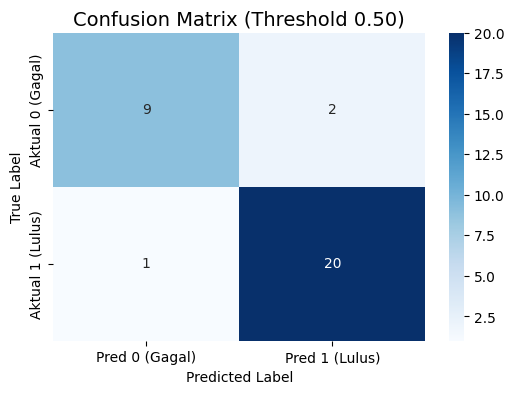


---
### 6. Perhitungan Metrik Evaluasi Manual
* **Accuracy:** (TP + TN) / Total = (20 + 9) / 32 = **0.9062** (90.62%)
* **Precision:** TP / (TP + FP) = 20 / (20 + 2) = **0.9091** (90.91%)
* **Recall / Sensitivity:** TP / (TP + FN) = 20 / (20 + 1) = **0.9524** (95.24%)
* **Specificity:** TN / (TN + FP) = 9 / (9 + 2) = **0.8182** (81.82%)
* **F1-Score:** 2 * (Precision * Recall) / (Precision + Recall) = 2 * (0.9091 * 0.9524) / (0.9091 + 0.9524) = **0.9302** (93.02%)

---
### 7. Makna Metrik dalam Konteks Kelulusan Sertifikasi
* **Accuracy:** Mengukur persentase keseluruhan prediksi yang tepat sasaran, yaitu peserta yang benar-benar diprediksi lulus ataupun tidak lulus secara akurat dibanding keseluruhan.
* **Precision:** Dari semua peserta yang **diprediksi lulus** oleh sistem, metrik ini menunjukkan seberapa banyak yang **benar-benar lulus**.
* **Recall/Sensitivity:** Dari semua peserta yang **sebenarnya lulus**, metrik ini menunjukkan seberapa banyak yang berhasil **ditebak/ditemukan sebagai lulus** oleh model.
* **Specificity:** Dari semua peserta yang **sebenarnya tidak lulus**, metrik ini menunjukkan seberapa tepat model **mendeteksi mereka sebagai tidak lulus**.
* **F1-Score:** Keseimbangan rata-rata harmonik antara Precision dan Recall, bermanfaat jika proporsi yang lulus dan tidak lulus tidak seimbang.


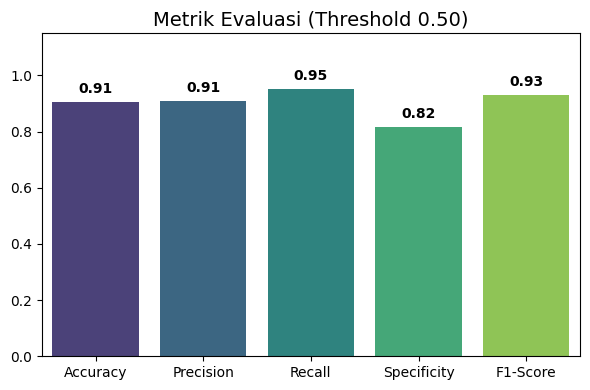


---
### 8. Perubahan Threshold Menjadi 0.60
Matriks untuk threshold 0.60:
```text
[[10, 1],
 [2, 19]]
```
* **Perubahan FP:** Berkurang dari 2 menjadi 1.
* **Perubahan FN:** Bertambah dari 1 menjadi 2.

---
### 9. Mengapa Menaikkan Threshold Menurunkan FP tetapi Menaikkan FN?
* Threshold adalah batas minimal (p) untuk mengelompokkan seseorang sebagai "lulus".
* Saat threshold dinaikkan (menjadi 0.60), sistem menjadi **lebih ketat (konservatif)** untuk meluluskan peserta.
* Akibat syarat yang lebih ketat, prediksi yang secara keliru dianggap lulus (FP) akan berkurang.
* Namun, beberapa peserta yang sebenarnya mampu (lulus) bisa jadi gagal mencapai standar persentase tinggi tersebut, sehingga salah terdeteksi sebagai tidak lulus (menambah FN).


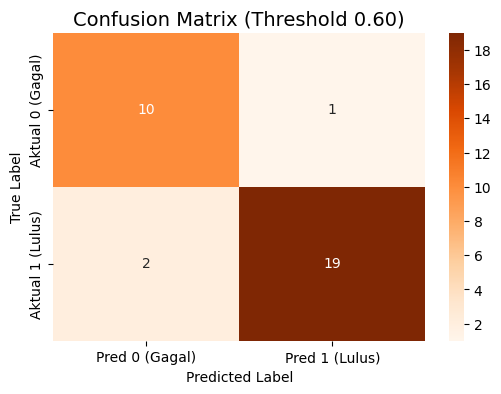


---
### 10. Verifikasi Hasil dengan Python
*Seluruh perhitungan di atas memverifikasi kode Bagian 6.9.5 di cell pertama.*
Hasil matriks maupun presisi/recall yang dihitung manual ini **sepenuhnya cocok** dengan output dari `evaluate(0.50)` dan `evaluate(0.60)` yang telah dijalankan sebelumnya.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import Markdown, display

# 4. Hitung manual dari pred05 (Threshold 0.50)
tn5, fp5, fn5, tp5 = 0, 0, 0, 0
for i in range(len(y)):
    if y[i]==1 and pred05[i]==1: tp5 += 1
    elif y[i]==0 and pred05[i]==0: tn5 += 1
    elif y[i]==0 and pred05[i]==1: fp5 += 1
    else: fn5 += 1

total5 = tn5 + fp5 + fn5 + tp5

# 6. Hitung Metrik Evaluasi
acc = (tp5 + tn5) / total5
pre = tp5 / (tp5 + fp5)
rec = tp5 / (tp5 + fn5)
spec = tn5 / (tn5 + fp5)
f1 = 2 * (pre * rec) / (pre + rec)

# 8. Hitung manual dari pred06 (Threshold 0.60)
tn6, fp6, fn6, tp6 = 0, 0, 0, 0
for i in range(len(y)):
    if y[i]==1 and pred06[i]==1: tp6 += 1
    elif y[i]==0 and pred06[i]==0: tn6 += 1
    elif y[i]==0 and pred06[i]==1: fp6 += 1
    else: fn6 += 1

# ==========================================
# BAGIAN 4 & 5: Teks + Gambar CM 0.50
# ==========================================
md_4_5 = f"""
### 4. Menghitung Total TP, TN, FP, dan FN (Threshold 0.50)
* **True Positive (TP):** {tp5}
* **True Negative (TN):** {tn5}
* **False Positive (FP):** {fp5}
* **False Negative (FN):** {fn5}
* **Total (TP + TN + FP + FN):** {tp5} + {tn5} + {fp5} + {fn5} = **{total5}** (Terbukti = 32)

---
### 5. Confusion Matrix
Bentuk matriks [[TN, FP], [FN, TP]]:
```text
[[{tn5}, {fp5}],
 [{fn5}, {tp5}]]
```
"""
display(Markdown(md_4_5))

plt.figure(figsize=(6, 4))
cm5 = np.array([[tn5, fp5], [fn5, tp5]])
sns.heatmap(cm5, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0 (Gagal)', 'Pred 1 (Lulus)'],
            yticklabels=['Aktual 0 (Gagal)', 'Aktual 1 (Lulus)'])
plt.title('Confusion Matrix (Threshold 0.50)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ==========================================
# BAGIAN 6 & 7: Teks + Gambar Metrik 0.50
# ==========================================
md_6_7 = f"""
---
### 6. Perhitungan Metrik Evaluasi Manual
* **Accuracy:** (TP + TN) / Total = ({tp5} + {tn5}) / 32 = **{acc:.4f}** ({acc*100:.2f}%)
* **Precision:** TP / (TP + FP) = {tp5} / ({tp5} + {fp5}) = **{pre:.4f}** ({pre*100:.2f}%)
* **Recall / Sensitivity:** TP / (TP + FN) = {tp5} / ({tp5} + {fn5}) = **{rec:.4f}** ({rec*100:.2f}%)
* **Specificity:** TN / (TN + FP) = {tn5} / ({tn5} + {fp5}) = **{spec:.4f}** ({spec*100:.2f}%)
* **F1-Score:** 2 * (Precision * Recall) / (Precision + Recall) = 2 * ({pre:.4f} * {rec:.4f}) / ({pre:.4f} + {rec:.4f}) = **{f1:.4f}** ({f1*100:.2f}%)

---
### 7. Makna Metrik dalam Konteks Kelulusan Sertifikasi
* **Accuracy:** Mengukur persentase keseluruhan prediksi yang tepat sasaran, yaitu peserta yang benar-benar diprediksi lulus ataupun tidak lulus secara akurat dibanding keseluruhan.
* **Precision:** Dari semua peserta yang **diprediksi lulus** oleh sistem, metrik ini menunjukkan seberapa banyak yang **benar-benar lulus**.
* **Recall/Sensitivity:** Dari semua peserta yang **sebenarnya lulus**, metrik ini menunjukkan seberapa banyak yang berhasil **ditebak/ditemukan sebagai lulus** oleh model.
* **Specificity:** Dari semua peserta yang **sebenarnya tidak lulus**, metrik ini menunjukkan seberapa tepat model **mendeteksi mereka sebagai tidak lulus**.
* **F1-Score:** Keseimbangan rata-rata harmonik antara Precision dan Recall, bermanfaat jika proporsi yang lulus dan tidak lulus tidak seimbang.
"""
display(Markdown(md_6_7))

plt.figure(figsize=(6, 4))
metrics = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score']
values = [acc, pre, rec, spec, f1]
ax = sns.barplot(x=metrics, y=values, palette='viridis', hue=metrics, legend=False)
plt.ylim(0, 1.15)
plt.title('Metrik Evaluasi (Threshold 0.50)', fontsize=14)
for i, v in enumerate(values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# BAGIAN 8 & 9: Teks + Gambar CM 0.60
# ==========================================
md_8_9 = f"""
---
### 8. Perubahan Threshold Menjadi 0.60
Matriks untuk threshold 0.60:
```text
[[{tn6}, {fp6}],
 [{fn6}, {tp6}]]
```
* **Perubahan FP:** Berkurang dari {fp5} menjadi {fp6}.
* **Perubahan FN:** Bertambah dari {fn5} menjadi {fn6}.

---
### 9. Mengapa Menaikkan Threshold Menurunkan FP tetapi Menaikkan FN?
* Threshold adalah batas minimal (p) untuk mengelompokkan seseorang sebagai "lulus".
* Saat threshold dinaikkan (menjadi 0.60), sistem menjadi **lebih ketat (konservatif)** untuk meluluskan peserta.
* Akibat syarat yang lebih ketat, prediksi yang secara keliru dianggap lulus (FP) akan berkurang.
* Namun, beberapa peserta yang sebenarnya mampu (lulus) bisa jadi gagal mencapai standar persentase tinggi tersebut, sehingga salah terdeteksi sebagai tidak lulus (menambah FN).
"""
display(Markdown(md_8_9))

plt.figure(figsize=(6, 4))
cm6 = np.array([[tn6, fp6], [fn6, tp6]])
sns.heatmap(cm6, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred 0 (Gagal)', 'Pred 1 (Lulus)'],
            yticklabels=['Aktual 0 (Gagal)', 'Aktual 1 (Lulus)'])
plt.title('Confusion Matrix (Threshold 0.60)', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ==========================================
# BAGIAN 10: Teks Penutup
# ==========================================
md_10 = f"""
---
### 10. Verifikasi Hasil dengan Python
*Seluruh perhitungan di atas memverifikasi kode Bagian 6.9.5 di cell pertama.*
Hasil matriks maupun presisi/recall yang dihitung manual ini **sepenuhnya cocok** dengan output dari `evaluate(0.50)` dan `evaluate(0.60)` yang telah dijalankan sebelumnya.
"""
display(Markdown(md_10))
